In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

In [3]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 30, 7.5, 150)

100%|██████████| 10000/10000 [6:35:51<00:00,  2.38s/it] 


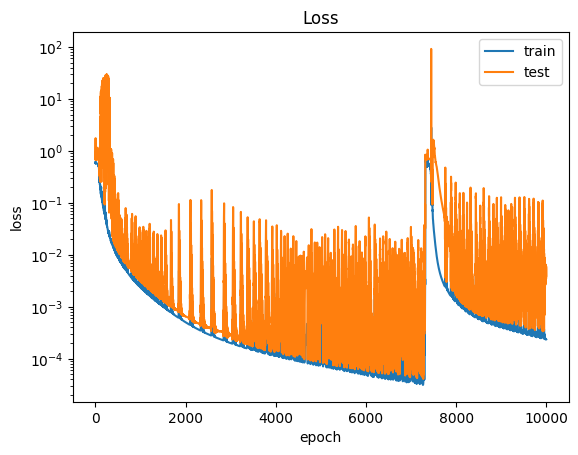

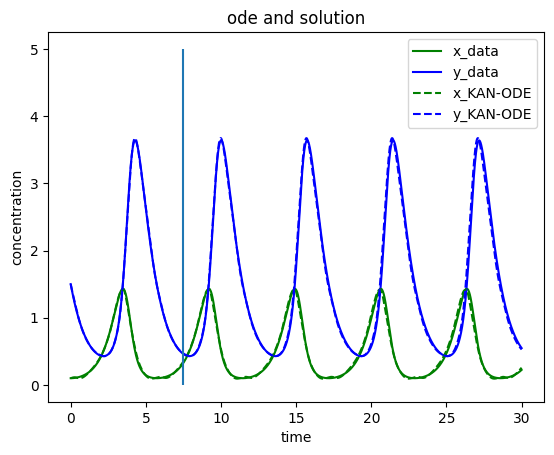

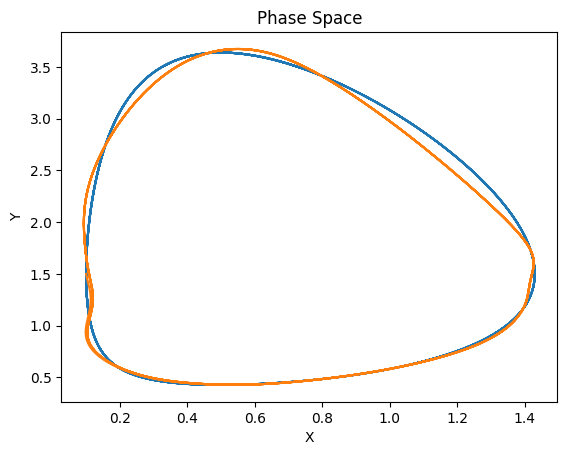

In [ ]:
module_path = os.path.abspath(os.path.join('..'))
saveDirectory = os.path.join(module_path, "savedModels")
kanODE.train(-1, saveDirectory = saveDirectory)
_, solution = kanODE.test()
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

100%|██████████| 1/1 [00:02<00:00,  2.27s/it]


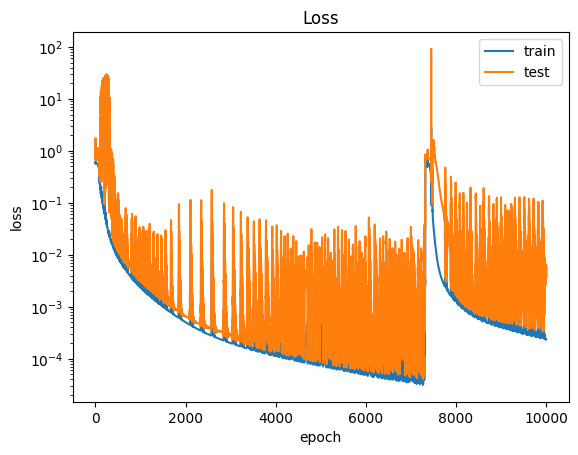

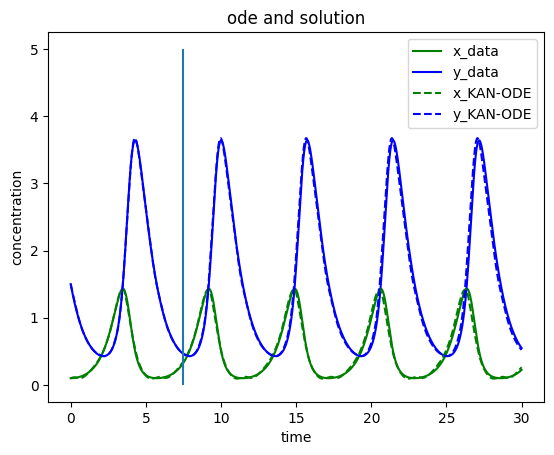

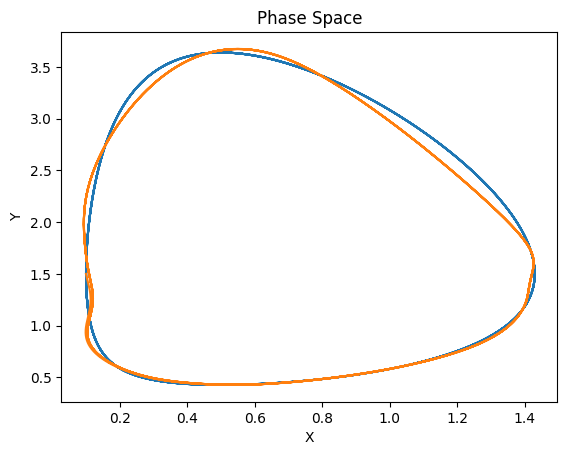

In [5]:
kanODE.train(1)
_, solution = kanODE.test()
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])